In [1]:
import random
import torch
from torch import nn
from torch.amp import GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

scaler = GradScaler(device=device)

# for mapping labels
label_encoder = preprocessing.LabelEncoder()

Using device: cuda


In [2]:
phone_map = {'aa': 0, 'ae': 1, 'ah': 2, 'ao': 3, 'aw': 4, 'ax': 5, 'ax-h': 6, 'axr': 7, 
'ay': 8, 'b': 9, 'bcl': 10, 'ch': 11, 'd': 12, 'dcl': 13, 'dh': 14, 'dx': 15, 
'eh': 16, 'el': 17, 'em': 18, 'en': 19, 'eng': 20, 'epi': 21, 'er': 22, 'ey': 23, 
'f': 24, 'g': 25, 'gcl': 26, 'h#': 27, 'hh': 28, 'hv': 29, 'ih': 30, 'ix': 31, 
'iy': 32, 'jh': 33, 'k': 34, 'kcl': 35, 'l': 36, 'm': 37, 'n': 38, 'ng': 39, 
'nx': 40, 'ow': 41, 'oy': 42, 'p': 43, 'pau': 44, 'pcl': 45, 'q': 46, 'r': 47, 
's': 48, 'sh': 49, 't': 50, 'tcl': 51, 'th': 52, 'uh': 53, 'uw': 54, 'ux': 55, 
'v': 56, 'w': 57, 'y': 58, 'z': 59, 'zh': 60}

# from TIMIT PHONCODE.DOC
voiced_map = {
    'voiced': {'b', 'd', 'g', 'dx', 'jh', 'z', 'zh', 'v', 'dh', 'm', 'n', 'ng', 'em', 'en', 'eng', 'nx', 'l', 'r', 'w', 'y', 'el', 'iy', 'ih', 'eh', 'ey', 'ae', 'aa', 'aw', 'ay', 'ah', 'ao', 'oy', 'ow', 'uh', 'uw', 'ux', 'er', 'ax', 'ix', 'axr', 'ax-h'},
    'unvoiced': {'p', 't', 'k', 'q', 'ch', 's', 'sh', 'f', 'th', 'hh', 'hv'},
    'none': {'h#', 'pau', 'epi', '1', '2'}
}

# invert the map so we can convert from phones to voicedness
phone_to_voiced_map = {}
for voicedness, phone_set in voiced_map.items():
    for phone in phone_set:
        phone_to_voiced_map[phone] = voicedness

def phone_to_voiced(phone):
    if phone in phone_to_voiced_map.keys():
        return phone_to_voiced_map[phone]
    return 'none'

In [3]:
# dataset definition
class AudioDataset(Dataset):
    def __init__(self, x, y):
        self.x         = x
        self.y         = y

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)

In [4]:
# define probe architecture

class ProbeNet(nn.Module):
    def __init__(self, embedding_dim):
        super(ProbeNet, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 200),
            nn.ReLU(),
            # nn.Dropout(0.2),
            nn.Linear(200, 3) # 2 voicedness qualities
        )
    
    def forward(self, x):
        x = self.layers(x)
        return x

In [5]:
def data_setup(embeddings, labels):
    # go from raw phones to voiced/unvoiced labels
    labels = list(map(phone_to_voiced, labels))

    # convert our phone labels into integers so we can fit to them
    labels_types = label_encoder.fit_transform(labels)

    print("Train records: " + str(len(embeddings)))

    train_set = AudioDataset(embeddings, labels_types)

    train_loader = DataLoader(
        dataset=train_set,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    print('Train batches: ' + str(len(train_loader)))

    return train_loader

In [ ]:
def train(model, loader, writer, epochs, criterion, optimizer, note):
    for epoch in tqdm(range(1, epochs + 1), "Training probe", 50):
        model.train()

        correct = 0
        total = 0

        # for data in tqdm(train_loader, desc="Training", total=len(train_loader)):
        for data in loader:
            inputs = data[0].to(device).float()
            targets = data[1].to(device)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predicted = torch.argmax(outputs, dim=1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        accuracy = 100.*correct / total
        writer.add_scalar(note, accuracy, epoch)

In [7]:
# set up stuff for whisper probe
# load whisper train embeddings
print("Loading saved whisper embeddings...")
whisper_train_embeddings = torch.load('data/saved_embeddings/whisper_train_embeddings.pt')
whisper_train_labels = torch.load('data/saved_embeddings/whisper_train_labels.pt')

print("Remapping + batching saved whisper embeddings....")
whisper_train_loader = data_setup(whisper_train_embeddings, whisper_train_labels)

whisper_probe = ProbeNet(1280).to(device)
optimizer = torch.optim.Adam(whisper_probe.parameters())
criterion = nn.CrossEntropyLoss()

Loading saved whisper embeddings...
Remapping + batching saved whisper embeddings....
Train records: 162459
Train batches: 1270


In [ ]:
# train the whisper probe
writer = SummaryWriter(comment='whisper voiceness probe')
train(whisper_probe, whisper_train_loader, writer, 50, criterion, optimizer, 'wav2vec voicedness probe accuracy')

torch.save(whisper_probe, 'whisper__voicedness_probe.pth')

Training probe: 100%|██████████| 50/50 [01:17<00:00,  1.55s/it]


In [ ]:
# initialize and train the wav2vec probe
print("Loading saved wav2vec embeddings...")
wav2vec_train_embeddings = torch.load('data/saved_embeddings/wav2vec_train_embeddings.pt')
wav2vec_train_labels = torch.load('data/saved_embeddings/wav2vec_train_labels.pt')

print("Remapping + batching saved wav2vec embeddings....")
wav2vec_train_loader = data_setup(wav2vec_train_embeddings, wav2vec_train_labels)

wav2vec_probe = ProbeNet(768).to(device)
optimizer = torch.optim.Adam(wav2vec_probe.parameters())
criterion = nn.CrossEntropyLoss()

writer = SummaryWriter(comment='wav2vec voicedness probe')
train(wav2vec_probe, wav2vec_train_loader, writer, 50, criterion, optimizer, 'wav2vec voicedness probe accuracy')

torch.save(wav2vec_probe, 'wav2vec_voicedness_probe.pth')

Loading saved wav2vec embeddings...
Remapping + batching saved wav2vec embeddings....
Train records: 162459
Train batches: 1270


Training probe: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]


In [10]:
# test wav2vec MOA probe
print("Loading saved test wav2vec embeddings...")
wav2vec_test_embeddings = torch.load('data/saved_embeddings/wav2vec_test_embeddings.pt')
wav2vec_test_labels = torch.load('data/saved_embeddings/wav2vec_test_labels.pt')

print("Remapping + batching saved test wav2vec embeddings....")
wav2vec_test_loader = data_setup(wav2vec_test_embeddings, wav2vec_test_labels)

wav2vec_probe.eval()

key_correct = {key: 0 for key in voiced_map.keys()}
key_total = {key: 0 for key in voiced_map.keys()}

correct = 0
total = 0

labels_for_confusion = []
predictions_for_confusion = []

for data in tqdm(wav2vec_test_loader, "Testing wav2vec probe", len(wav2vec_test_loader)):
    inputs = data[0].to(device).float()
    targets = data[1].to(device)

    outputs = wav2vec_probe(inputs)

    predicted = torch.argmax(outputs, dim=1)
    total += predicted.size(0)
    correct += predicted.eq(targets).sum().item()

    cpu_target = targets.cpu()
    cpu_predicted = predicted.cpu()

    for i in range(len(outputs)):
        voiced_targets = label_encoder.inverse_transform(cpu_target)
        voiced_predicted = label_encoder.inverse_transform(cpu_predicted)

        labels_for_confusion.extend(voiced_targets)
        predictions_for_confusion.extend(voiced_predicted)
        
        for j in range(len(voiced_targets)):
            true_key = voiced_targets[i]
            key_total[true_key] += 1

            if true_key == voiced_predicted[i]:
                key_correct[true_key] += 1
    
accuracy = 100.*correct/total
writer.add_scalar('wav2vec probe test accuracy', accuracy)

for key in key_total.keys():
    key_accuracy = 100.*key_correct[key]/key_total[key]
    writer.add_scalar(key + " accuracy: ", key_accuracy)


Loading saved test wav2vec embeddings...
Remapping + batching saved test wav2vec embeddings....
Train records: 59071
Train batches: 462


Testing wav2vec probe: 100%|██████████| 462/462 [00:15<00:00, 30.33it/s]


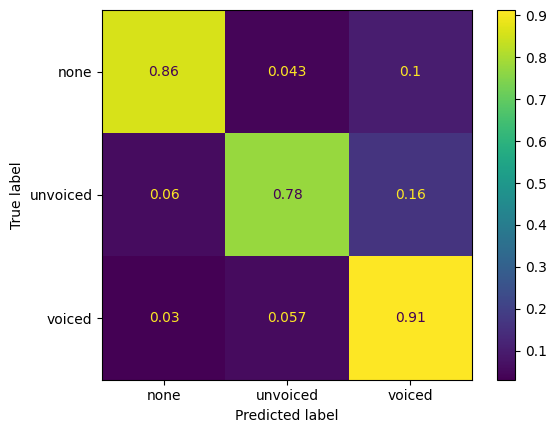

In [13]:
# print(key_correct)
# print(key_total)

cm = confusion_matrix(labels_for_confusion, predictions_for_confusion, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot()

# print(labels_for_confusion[1:10])

In [ ]:
# whisper MOA test
print("Loading saved test whisper embeddings...")
whisper_test_embeddings = torch.load('data/saved_embeddings/whisper_test_embeddings.pt')
whisper_test_labels = torch.load('data/saved_embeddings/whisper_test_labels.pt')

print("Remapping + batching saved test whisper embeddings....")
wav2vec_test_loader = data_setup(whisper_test_embeddings, whisper_test_labels)

whisper_probe.eval()

key_correct = {key: 0 for key in voiced_map.keys()}
key_total = {key: 0 for key in voiced_map.keys()}

correct = 0
total = 0

labels_for_confusion = []
predictions_for_confusion = []

for data in tqdm(whisper_test_loader, "Testing whisper probe", len(whisper_test_loader)):
    inputs = data[0].to(device).float()
    targets = data[1].to(device)

    outputs = whisper_probe(inputs)

    predicted = torch.argmax(outputs, dim=1)
    total += predicted.size(0)
    correct += predicted.eq(targets).sum().item()

    cpu_target = targets.cpu()
    cpu_predicted = predicted.cpu()

    for i in range(len(outputs)):
        voiced_targets  = label_encoder.inverse_transform(cpu_target)
        voiced_predicted = label_encoder.inverse_transform(cpu_predicted)

        labels_for_confusion.extend(voiced_targets)
        predictions_for_confusion.extend(voiced_predicted)
        
        for j in range(len(voiced_targets)):
            true_key = voiced_targets[i]
            key_total[true_key] += 1


            if true_key == voiced_predicted[i]:
                key_correct[true_key] += 1
    
accuracy = 100.*correct/total
writer.add_scalar('whisper probe test accuracy', accuracy)

for key in key_total.keys():
    key_accuracy = 100.*key_correct[key]/key_total[key]
    writer.add_scalar(key + " accuracy: ", key_accuracy)


In [ ]:
# whisper stats
print(key_correct)
print(key_total)

cm = confusion_matrix(labels_for_confusion, predictions_for_confusion, average="recall")
ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot()

print(labels_for_confusion[1:10])